In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pyprojroot import here

In [15]:
RAW_DATA_DIR = here() / "data" / "raw"
INTERIM_DATA_DIR = here() / "data" / "interim"
PROCESSED_DATA_DIR = here() / "data" / "processed"
RESULTS_DATA_DIR = here() / "results"

In [3]:
df = pd.read_csv(INTERIM_DATA_DIR/"crime_count_2015-2025.csv", encoding="latin-1")

### Crime counts per year dataframe dictionary

In [5]:
crime_count_dict = dict.fromkeys(df['year'].unique().astype(int).tolist())
df['year'] = df['year'].astype(int)
for name, _ in crime_count_dict.items():
    dfyear = df[df['year'] == name].fillna(0).copy()
    crime_count_dict[name] = dfyear

### Histograms per year

In [13]:
def histogram(dataframe, year=int):
    plt.figure(figsize=(8, 5))
    plt.hist(dataframe['crime_count'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.title(f'{year} Distribution of Crime Rates per Municipality', fontsize=14, fontweight='bold')
    plt.xlabel('Crime Count', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig(RESULTS_DATA_DIR/f'descriptive_analysis/{year}_crimerate_hist.png') 

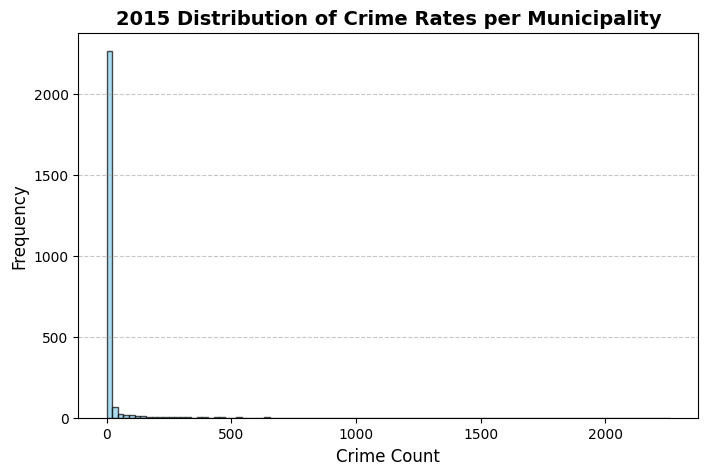

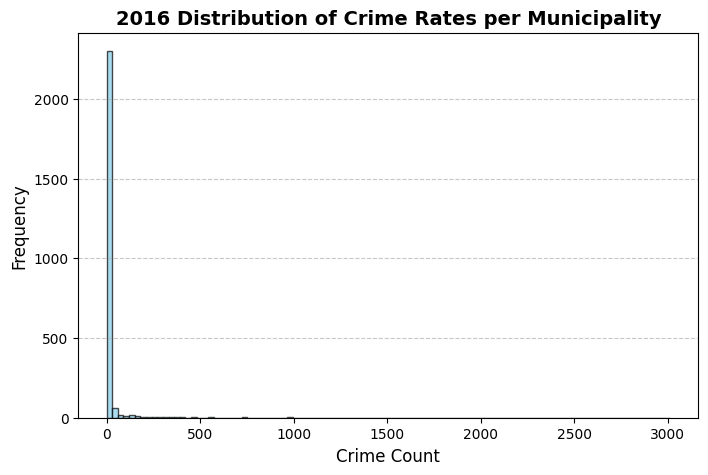

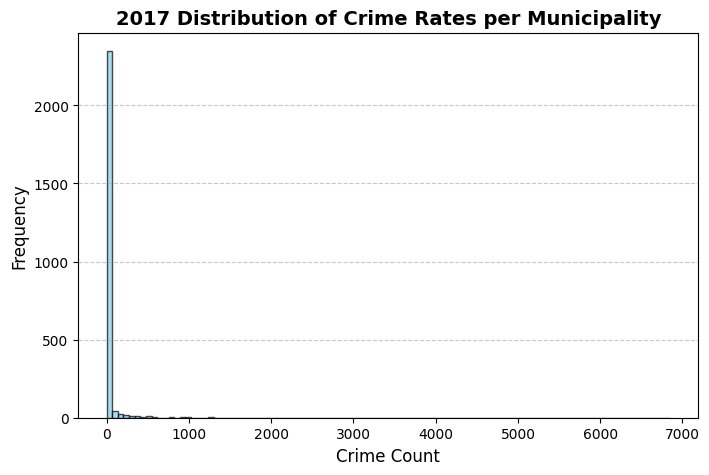

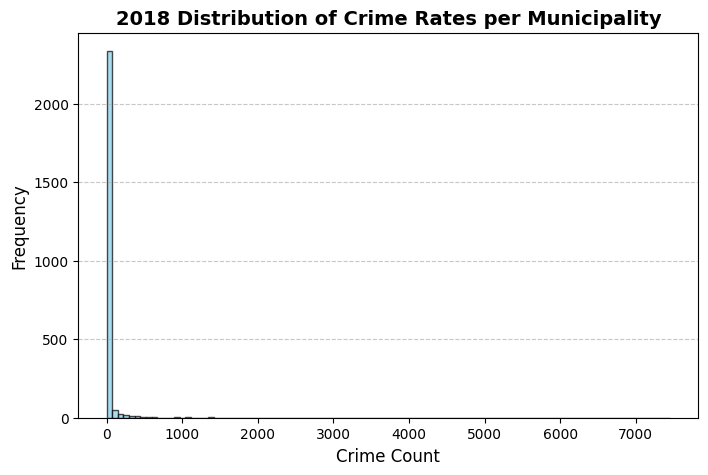

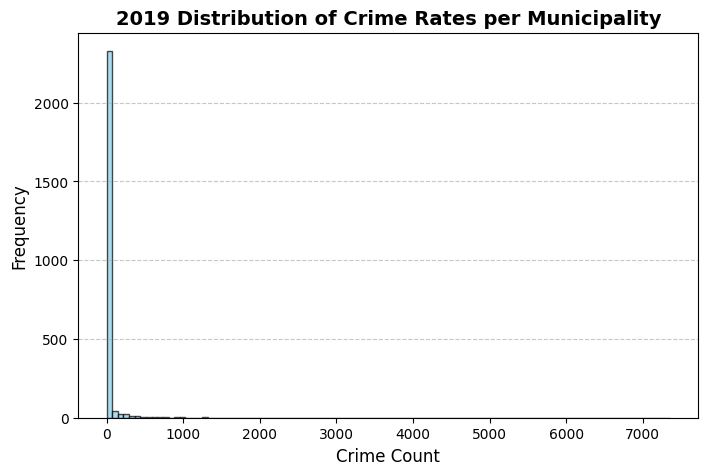

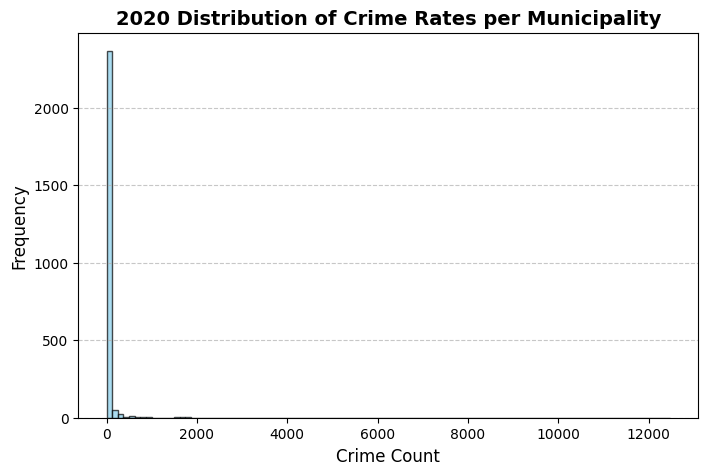

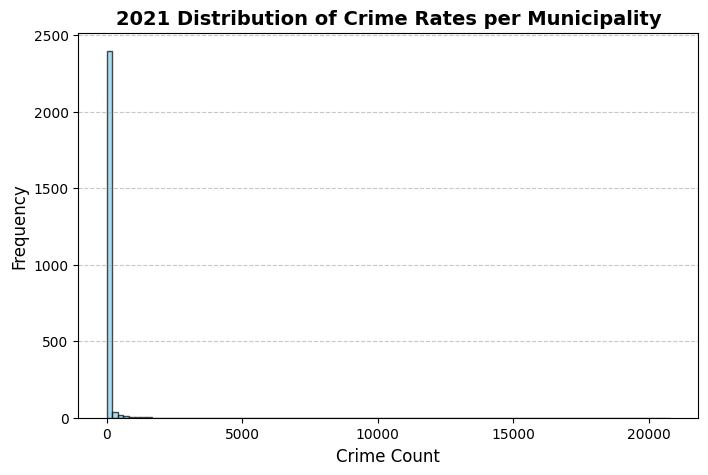

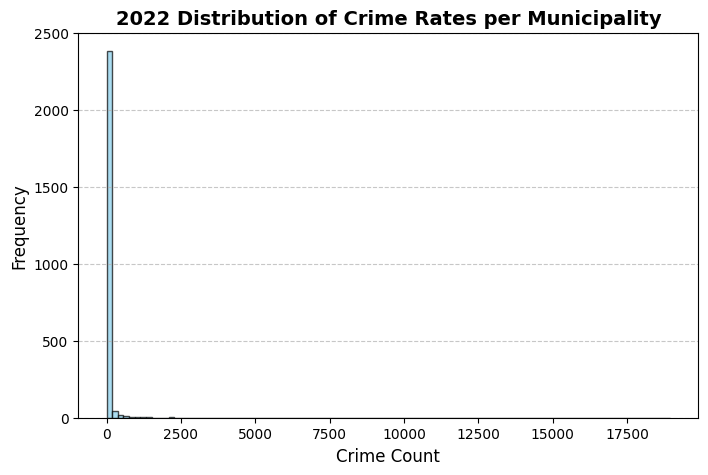

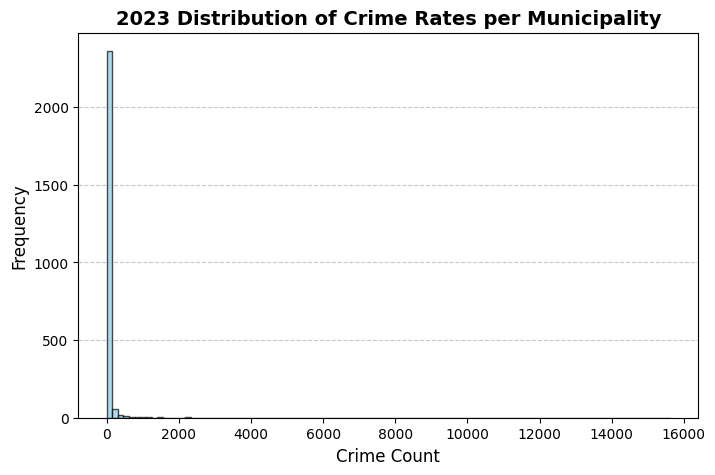

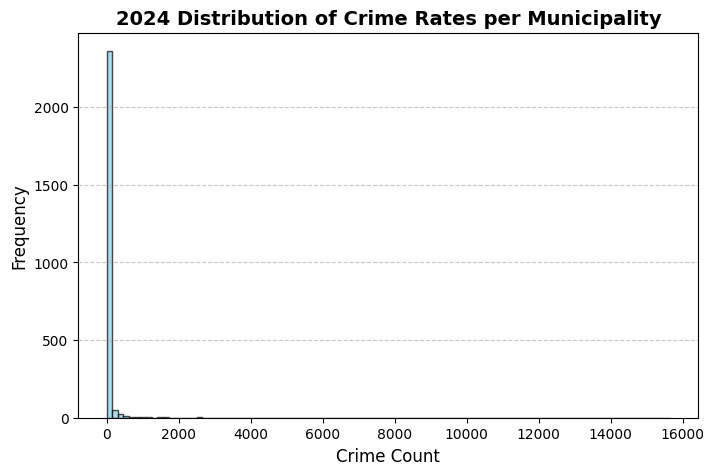

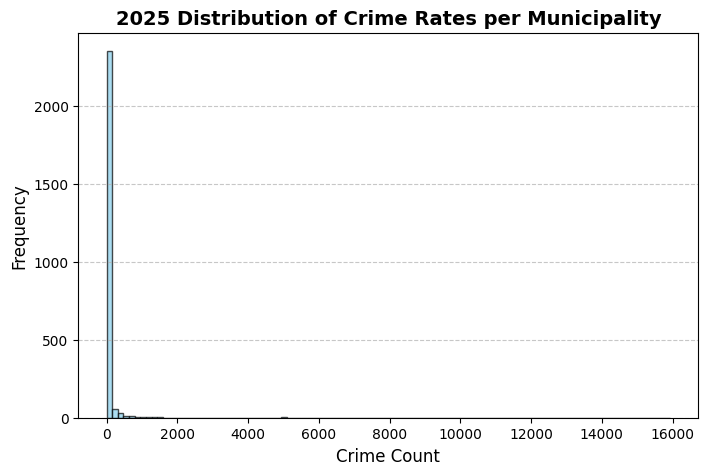

In [16]:
for name, values in crime_count_dict.items():
    histogram(values, name)

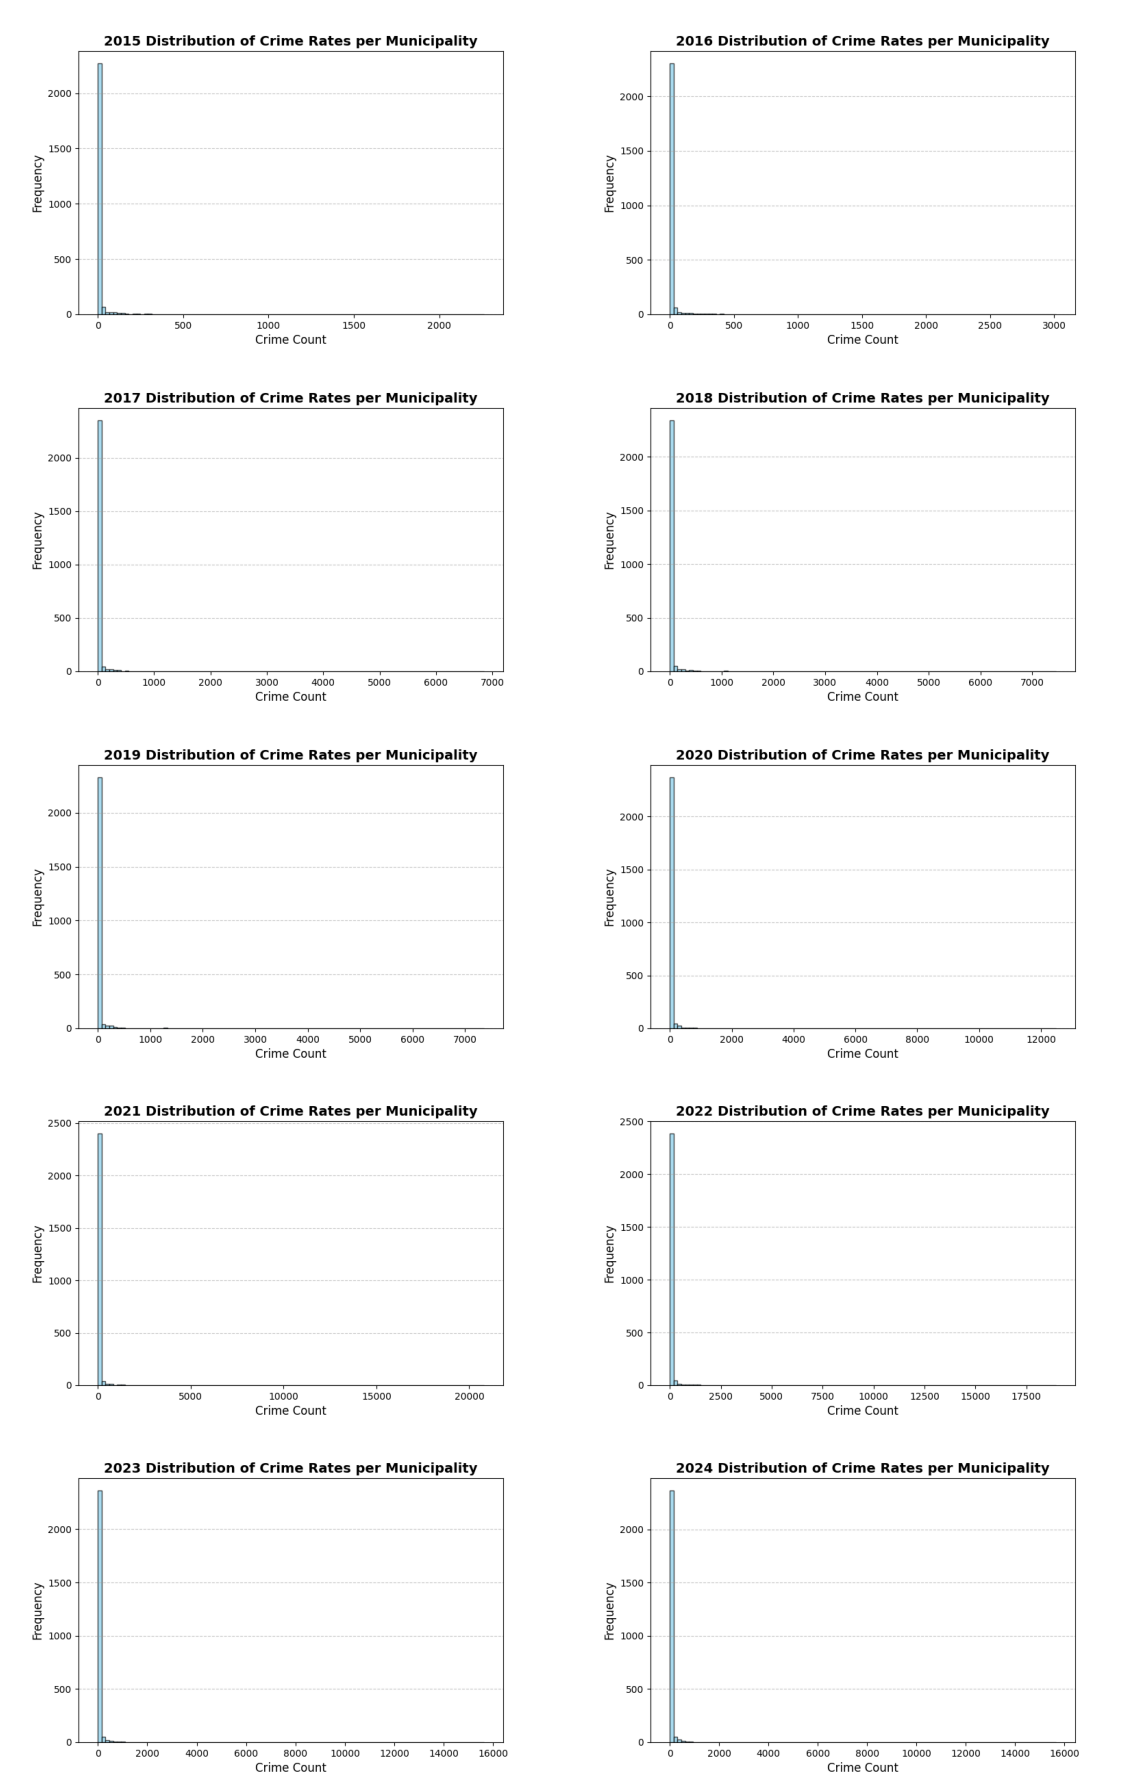

In [20]:
image_paths = [
    RESULTS_DATA_DIR/f'descriptive_analysis/2015_crimerate_hist.png', RESULTS_DATA_DIR/f'descriptive_analysis/2016_crimerate_hist.png',
    RESULTS_DATA_DIR/f'descriptive_analysis/2017_crimerate_hist.png', RESULTS_DATA_DIR/f'descriptive_analysis/2018_crimerate_hist.png',
    RESULTS_DATA_DIR/f'descriptive_analysis/2019_crimerate_hist.png', RESULTS_DATA_DIR/f'descriptive_analysis/2020_crimerate_hist.png',
    RESULTS_DATA_DIR/f'descriptive_analysis/2021_crimerate_hist.png', RESULTS_DATA_DIR/f'descriptive_analysis/2022_crimerate_hist.png',
    RESULTS_DATA_DIR/f'descriptive_analysis/2023_crimerate_hist.png', RESULTS_DATA_DIR/f'descriptive_analysis/2024_crimerate_hist.png'
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes_flat = axes.flatten()

for i, img_path in enumerate(image_paths):
    ax = axes_flat[i]
    
    img = mpimg.imread(img_path)
    ax.imshow(img)
    
    ax.axis('off') 

plt.tight_layout()
plt.savefig(RESULTS_DATA_DIR/f'descriptive_analysis/2015-2024_crime_counts_histograms.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

### Summary per year

In [23]:
summary_dfs = dict.fromkeys(df['year'].unique().astype(int).tolist())
for name, value in crime_count_dict.items():
    summary_dfs[name] = value['crime_count'].agg([
        'min', 'max', 'mean', 'median', 'std', 'skew', 'kurt'
    ]).to_frame().T
    summary_dfs[name]['missing'] = value['crime_count'].isna().sum()
    summary_dfs[name]['observations'] = len(value['crime_count'])

combined_summary_df = pd.concat(summary_dfs.values(), keys=summary_dfs.keys())

In [25]:
combined_summary_df.to_csv(RESULTS_DATA_DIR/f"descriptive_analysis/data_descriptive_summary.csv")

### Boxplots

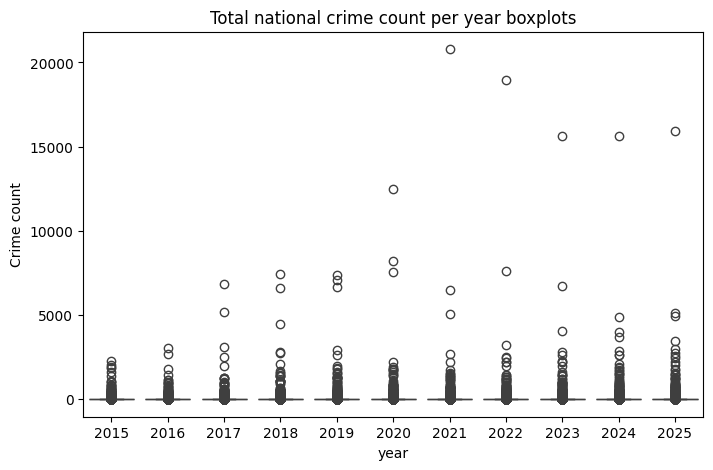

In [29]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='year', y='crime_count')
plt.ylabel("Crime count")
plt.title('Total national crime count per year boxplots')
plt.savefig(RESULTS_DATA_DIR/f'descriptive_analysis/full_boxplots.png') 
plt.show()
plt.close()

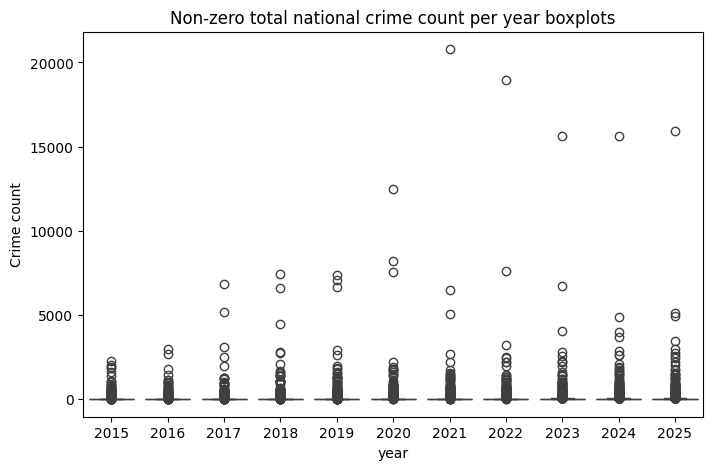

In [33]:
non_zero_df = df[df['crime_count'] > 0].copy()
plt.figure(figsize=(8, 5))
sns.boxplot(data=non_zero_df, x='year', y='crime_count')
plt.ylabel("Crime count")
plt.title('Non-zero total national crime count per year boxplots')
plt.savefig(RESULTS_DATA_DIR/f'descriptive_analysis/NZ_boxplots.png') 
plt.show()
plt.close()